# 05 — Análisis de sensibilidad del criterio de éxito

¿Cuánto cambia la tasa de captura de **una misma política aprendida** si se cambia **un supuesto** de la
evaluación? Es la Q-table evaluada en vivo (Q-Learning, ε decreciente, semilla 4), identificada por el SHA-256
de su `q.npy`. Todo se mide **en el simulador**, con los parámetros físicos del servidor y **sin reentrenar**.

Qué **no** es este análisis:
- **No demuestra cumplimiento del criterio** (> 90 % en < 40 pasos sobre d₀ ∈ [5, 40] m). Las variantes
  cambian supuestos de la evaluación, y solo la forma de la distribución sobre [5, 40] m es una lectura
  alternativa del enunciado. El subconjunto [5, 30] m y los presupuestos mayores **no** lo son.
- **No identifica la causa** del déficit ni descarta errores de implementación: la política, la percepción y el
  control son los mismos en todas las variantes.
- La política se entrenó con el supuesto base; con otros supuestos, una política reentrenada podría comportarse
  distinto.

Reproducir: `python -m src.sensitivity --n 5000` (≈ 1 min). El ruido del simulador se siembra por episodio,
(semilla, índice), así que todas las variantes comparten inicios y ruido episodio a episodio.

In [1]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
os.chdir("/workspace") if os.path.isdir("/workspace/src") else None
from src import plots

S = json.load(open("notebooks/artifacts/sensitivity.json"))
pc = S["policy_config"]
display(Markdown(f"""| campo | valor |
|---|---|
| política | `{S['policy_run']}` ({pc['algorithm']}, α = {pc['alpha']}, γ = {pc['gamma']}, {pc['n_episodes']} episodios, semilla {pc['seed']}) |
| SHA-256 de `q.npy` | `{S['q_sha256'][:16]}…` |
| huella del código `src/` | `{S['source_sha256'][:16]}…` |
| episodios por variante | {S['n']} |
| semilla (inicios y ruido por episodio) | {S['seed']} |
| primeros 40 ciclos idénticos con tope de 60 | {S['budget_run_matches_40_cycle_run']} |"""))

lines = ["| grupo | variante | definición | inicios con d₀ ≥ 30 m | captura < 40 | captura ≤ 40 |", "|---|---|---|---|---|---|"]
for r in S["results"]:
    if r["group"] == "budget":
        continue
    lt, le = r["rates"]["<40"], r["rates"]["<=40"]
    lines.append(f"| {r['group']} | {r['variant']} | {r['definition']} | {r['share_d0_ge_30']:.1%} | "
                 f"{lt['rate']:.1%} ± {lt['stderr']:.1%} | {le['rate']:.1%} |")
display(Markdown("\n".join(lines)))

| campo | valor |
|---|---|
| política | `notebooks/artifacts/runs/qlearning_eps_decay_1.0_to_0.1/seed_4` (qlearning, α = 0.03, γ = 0.99, 20000 episodios, semilla 4) |
| SHA-256 de `q.npy` | `a76555e35466f294…` |
| huella del código `src/` | `55fb92825704fe9d…` |
| episodios por variante | 5000 |
| semilla (inicios y ruido por episodio) | 11 |
| primeros 40 ciclos idénticos con tope de 60 | True |

| grupo | variante | definición | inicios con d₀ ≥ 30 m | captura < 40 | captura ≤ 40 |
|---|---|---|---|---|---|
| baseline | as implemented | d0 uniform on [5, 40] m, player sensing, fewer than 40 cycles | 28.0% | 73.6% ± 0.6% | 76.4% |
| distribution | area | uniform over the annulus area: density proportional to d (more far starts) on [5, 40] m | 44.6% | 59.2% ± 0.7% | 62.6% |
| distribution | near | triangular with mode at d_min: density proportional to (d_max - d) (more near starts) on [5, 40] m | 7.8% | 92.5% ± 0.4% | 94.0% |
| subset | d0 in [5, 30] m | uniform on [5, 30] m: an easier subset, NOT the stated range | 0.0% | 96.8% ± 0.2% | 98.1% |
| information | once | true ball position given to the estimator once, at reset; afterwards normal sensing | 28.0% | 79.8% ± 0.6% | 82.6% |
| information | truth | true (d, theta) replaces the observation at every step (continuous privileged access) | 28.0% | 79.7% ± 0.6% | 82.5% |

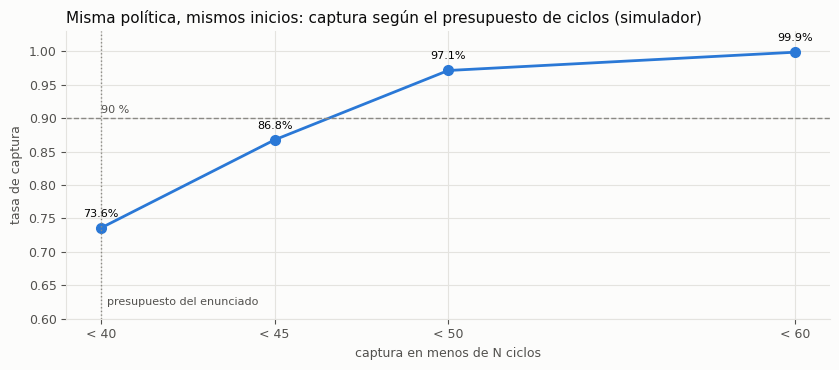

In [2]:
b = next(r for r in S["results"] if r["group"] == "budget")
pts = [(39, "<40"), (44, "<45"), (49, "<50"), (59, "<60")]
x = [c + 1 for c, _ in pts]; y = [b["rates"][k]["rate"] for _, k in pts]
fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.plot(x, y, "-o", color=plots.SERIES[0], linewidth=2, markersize=7)
for xi, yi in zip(x, y):
    ax.annotate(f"{yi:.1%}", (xi, yi), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8)
ax.axhline(0.9, color=plots.REF, linestyle="--", linewidth=1)
ax.annotate("90 %", (40, 0.9), xytext=(0, 4), textcoords="offset points", fontsize=8, color=plots.TEXT_2)
ax.axvline(40, color=plots.REF, linewidth=1, linestyle=":")
ax.annotate("presupuesto del enunciado", (40, 0.62), xytext=(4, 0), textcoords="offset points", fontsize=8, color=plots.TEXT_2)
ax.set_ylim(0.6, 1.03); ax.set_xticks(x, [f"< {v}" for v in x])
plots.style(ax, "Misma política, mismos inicios: captura según el presupuesto de ciclos (simulador)",
            "captura en menos de N ciclos", "tasa de captura")
fig.tight_layout(); fig.savefig("notebooks/artifacts/fig_sensitivity_budget.png", dpi=200)

## Lectura

- **Forma de la distribución sobre el rango del enunciado.** La tasa va de ≈ 59 % (densidad ∝ d: más inicios
  lejanos) a ≈ 93 % (triangular, más inicios cercanos), pasando por ≈ 74 % con la uniforme. El enunciado fija el
  rango [5, 40] m pero no la forma, y alcanzar o no 90 % depende de ese supuesto. La triangular **no** está
  más justificada que la uniforme; se incluye solo para cuantificar la sensibilidad.
- **Subconjunto [5, 30] m (≈ 97 %).** Muestra que la política resuelve los inicios cercanos. **No** demuestra
  cumplimiento sobre el rango completo.
- **Presupuesto de ciclos.** Con los mismos episodios, esta política pasa de ≈ 74 % (< 40) a ≈ 87 % (< 45) y
  ≈ 97 % (< 50). Unas 9 de cada 10 de sus fallas bajo < 40 se convierten en capturas con hasta 10 ciclos más:
  van hacia el balón pero no llegan a tiempo. Eso no implica que otra política no pudiera lograrlo en 40 ciclos.
- **Información.** Dar la posición del balón **una vez**, al reset, sube la tasa a ≈ 80 %; darla **en cada paso**
  no agrega nada más (≈ 80 %). Para esta política, la ganancia viene de ahorrarse la búsqueda inicial, y el
  seguimiento posterior del estimador no aparece como factor limitante. Ninguna de las dos variantes alcanza 90 %.

**Conclusión:** bajo el rango [5, 40] m del enunciado, que esta política supere 90 % depende sobre todo de dos
supuestos que el enunciado no fija: la forma de la distribución de d₀ y cuánto tiempo físico representa un
«paso». Este análisis no establece que el criterio sea imposible, que la interpretación explique todo el
déficit, ni que no haya errores; cuantifica cuánto pesa cada supuesto para la política actual.